# Master Teacher count and NAT performance — Correlation Analysis
A correlation analysis of NAT performance of Grade 6 students across 5 regions (CAR, Region I, Region III, Region VIII, Region IX) to number of Master Teachers present in every individual schools.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

## Load the dataset

In [60]:
server = r'LAPTOP-OCKRNGU5\SQLEXPRESS'
database = 'DepEDdb'

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+18+for+SQL+Server"
    "&trusted_connection=yes"
    "&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)

query = """
SELECT
    -- School information
    e.school_id,
    e.school_name,
    e.region,
    e.division,
    -- Master teacher positions
    p.es_master_teacher_iv,
    p.es_master_teacher_iii,
    p.es_master_teacher_ii,
    p.es_master_teacher_i,
    -- Regular teacher positions for context
    p.es_teacher_iii,
    p.es_teacher_ii,
    p.es_teacher_i,
    -- NAT results
    n.n_test_takers,
    n.filipino_mps,
    n.english_mps,
    n.math_mps,
    n.science_mps,
    n.araling_panlipunan_mps,
    n.overall_mps
FROM DepEDdb.dbo.enrollment_2023_24 AS e
JOIN DepEDdb.dbo.personnel_2023_24 AS p
    ON e.school_id = p.school_id
JOIN DepEDdb.dbo.nat_2023_24 AS n
    ON e.school_id = n.school_id;
"""

deped_master = pd.read_sql(query, engine)

## Data Description

Initial inspection reveals 6,636 school records across 5 regions. 
Key columns for this analysis include teacher position (especially master teacher positions) 
(es_teacher_i through es_master_teacher_iv), grade-level 
enrollment by gender, and NAT subject scores for Grade 6.

Notable data quality issues identified:
- Teacher position columns contain significant null values
- Teacher-student ratio produces inf values for schools with 
  zero recorded teachers
- NAT scores reflect Grade 6 performance only for SY 2023-24

In [61]:
deped_master.describe()

,school_id,es_master_teacher_iv,es_master_teacher_iii,es_master_teacher_ii,es_master_teacher_i,es_teacher_iii,es_teacher_ii,es_teacher_i,n_test_takers,filipino_mps,english_mps,math_mps,science_mps,araling_panlipunan_mps,overall_mps
count,6636.000000,1.0,68.000000,1258.000000,2547.000000,5465.000000,3036.000000,4658.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000
mean,171684.380199,1.0,1.176471,1.445946,1.548881,6.543824,2.205863,3.636325,7.950723,66.052370,63.672121,56.397593,54.014724,62.940507,60.646940
std,118952.059550,NaN,0.455191,1.018846,1.261345,6.220741,2.030276,4.475926,8.948053,12.932123,16.828350,19.475852,15.773303,17.121023,14.621344
min,100000.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14.814815,12.962963,7.692308,9.259259,9.259259,11.940299
25%,106051.750000,1.0,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,3.000000,57.407407,51.851852,40.384615,41.666667,49.626136,49.626866
50%,123212.500000,1.0,1.000000,1.000000,1.000000,5.000000,2.000000,2.000000,6.000000,66.666667,65.432099,55.769231,54.074074,64.814815,61.567164
75%,135630.250000,1.0,1.000000,1.000000,2.000000,8.000000,3.000000,4.000000,10.000000,75.661376,76.543210,72.435897,66.666667,76.829450,72.395833
max,502375.000000,1.0,3.000000,11.000000,17.000000,75.000000,28.000000,74.000000,117.000000,98.456790,100.000000,100.000000,92.592593,100.000000,92.910448


## DataFrame Column Overview

Teacher columns (es_master_teacher_iv, es_master_teacher_iii, es_master_teacher_ii, etc.) is in float and shall be converted to integers for accuracy.

In [62]:
deped_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 6636 entries, 0 to 6635
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   school_id               6636 non-null   int64  
 1   school_name             6636 non-null   str    
 2   region                  6636 non-null   str    
 3   division                6636 non-null   str    
 4   es_master_teacher_iv    1 non-null      float64
 5   es_master_teacher_iii   68 non-null     float64
 6   es_master_teacher_ii    1258 non-null   float64
 7   es_master_teacher_i     2547 non-null   float64
 8   es_teacher_iii          5465 non-null   float64
 9   es_teacher_ii           3036 non-null   float64
 10  es_teacher_i            4658 non-null   float64
 11  n_test_takers           6636 non-null   int64  
 12  filipino_mps            6636 non-null   float64
 13  english_mps             6636 non-null   float64
 14  math_mps                6636 non-null   float64
 15

## Data Cleaning
Missing value imputations. Replacing nulls with 0 and converting teacher columns into integers for better and accurate data aggregation

Null values was found across different columns of the dataframe and all 7 teacher columns is in float and has to be converted into integer

In [63]:
# List of the specific teacher columns to fill NaN values and convert to integers
teacher_cols = ['es_master_teacher_iv', 'es_master_teacher_iii',
                'es_master_teacher_ii', 'es_master_teacher_i',
                'es_teacher_iii', 'es_teacher_ii', 'es_teacher_i']

deped_master[teacher_cols] = deped_master[teacher_cols].fillna(0).astype(int)

deped_master['total_master_teachers'] = (deped_master['es_master_teacher_i'] + 
    deped_master['es_master_teacher_ii'] + deped_master['es_master_teacher_iii'] + 
    deped_master['es_master_teacher_iv'])

deped_master['has_master_teacher'] = deped_master['total_master_teachers'] > 0

## Added columns — Master Teachers and Overall Teacher Summaries

As we need the total number of master teachers ('total_master_teachers') per school for the correlation analysis and the overall number of teachers as supporting evidence.

In [64]:
deped_master['total_master_teachers'] = (deped_master['es_master_teacher_i'] + 
    deped_master['es_master_teacher_ii'] + deped_master['es_master_teacher_iii'] + 
    deped_master['es_master_teacher_iv'])

deped_master['has_master_teacher'] = deped_master['total_master_teachers'] > 0

deped_master['total_teachers'] = (deped_master['es_master_teacher_i'] + 
    deped_master['es_master_teacher_ii'] + deped_master['es_master_teacher_iii'] + 
    deped_master['es_master_teacher_iv'] + deped_master['es_teacher_iii'] + deped_master['es_teacher_ii'] + deped_master['es_teacher_i']).astype(int)

## Number of Schools with no recorded teachers

As per previous analysis, the number of schools with no recorded teachers is the same — 814.

In [65]:
print((deped_master['total_teachers'] == 0).sum())

814


## DataFrame Table Overview

In [ ]:
deped_master.style.format({
    'es_master_teacher_iv': '{:,.0f}',
    'es_master_teacher_iii': '{:,.0f}',
    'es_master_teacher_ii': '{:,.0f}',
    'es_master_teacher_i': '{:,.0f}',
    'es_teacher_iii': '{:,.0f}',
    'es_teacher_ii': '{:,.0f}',
    'es_teacher_i': '{:,.0f}'
})

In [67]:
master_teacher_ratio = deped_master[[
    'school_id',
    'school_name',
    'region',
    'total_master_teachers',
    'total_teachers',
    'has_master_teacher',
    'n_test_takers',
    'filipino_mps',
    'english_mps',
    'math_mps',
    'science_mps',
    'araling_panlipunan_mps',
    'overall_mps'
]].copy()

# Filter out schools with no recorded teachers at all
master_teacher_ratio = master_teacher_ratio[master_teacher_ratio['total_teachers'] > 0]

## Calculating for the Correlation of Total Master Teachers to the Overall NAT Perfomance

Finding if the Total count of Master Teachers in a school affects its Overall NAT Performance

In [68]:
correlation = master_teacher_ratio['total_master_teachers'].corr(master_teacher_ratio['overall_mps'])
print(f"Correlation between total master teachers and overall MPS: {correlation:.3f}")

Correlation between total master teachers and overall MPS: 0.049


## Chart — Scatterplot with a trendline

Visual representation of the correlation of Total Master Teachers to the Overall NAT Performance

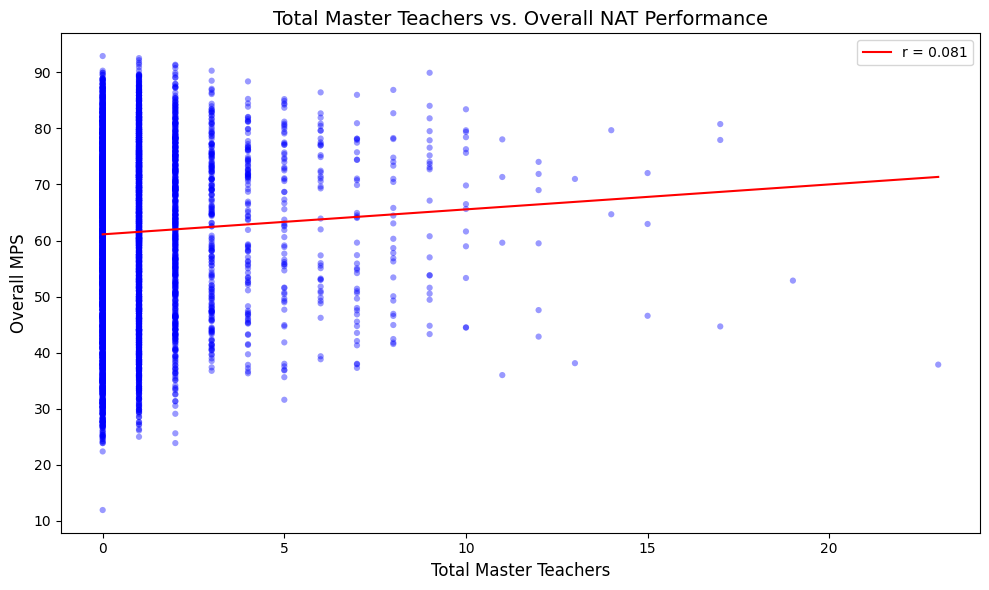

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(master_teacher_ratio['total_master_teachers'], 
            master_teacher_ratio['overall_mps'],
            alpha=0.4,
            edgecolors='none',
            color='blue',
            s=20)

# Trend line
z = np.polyfit(master_teacher_ratio['total_master_teachers'], master_teacher_ratio['overall_mps'], 1)
p = np.poly1d(z)
x_line = np.linspace(master_teacher_ratio['total_master_teachers'].min(), master_teacher_ratio['total_master_teachers'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5, label=f'r = 0.081')

ax.set_xlabel('Total Master Teachers', fontsize=12)
ax.set_ylabel('Overall MPS', fontsize=12)
ax.set_title('Total Master Teachers vs. Overall NAT Performance', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## Correlation Analysis — Total Master Teacher vs NAT Performance

### Finding
The Pearson correlation between total Master Teachers and overall 
NAT MPS is **r = 0.049**, indicating a very weak positive correlation between the two variables.

### Interpretation
There appears to be a very weak positive influence that the more Master Teachers there are in a school suggests a marginal association between Master Teacher presence 
and NAT performance, though the relationship is too weak to draw meaningful conclusions about instructional quality. But we need to also take note of the huge variance between data points with zero, one, and 2 Master Teachers per school.

### Data Quality Observation
Initial analysis included 814 schools with no recorded teacher positions. These schools produced an inflated correlation of r = 0.081 and an average MPS higher than expected, likely due to small sample sizes producing volatile NAT scores. After excluding these schools, the correlation dropped to r = 0.049, suggesting the initial result was partially driven by data quality issues rather than true signal.

### Important Caveats
- Teacher position data contains significant null values treated as zero — this likely undercounts actual teachers per school and may suppress the true correlation
- Analysis is limited to 5 regions and may not reflect nationwide patterns
- Correlation measures linear relationships only — a threshold or non-linear effect cannot be ruled out

## Average NAT Performance by Number of Master Teachers

The correlation analysis showed that there is a weak positive correlation between the Total number of Master Teachers in a school to their Overall NAT Scores. With this, we would like to look at the average NAT performance of schools per number of Master Teachers present.

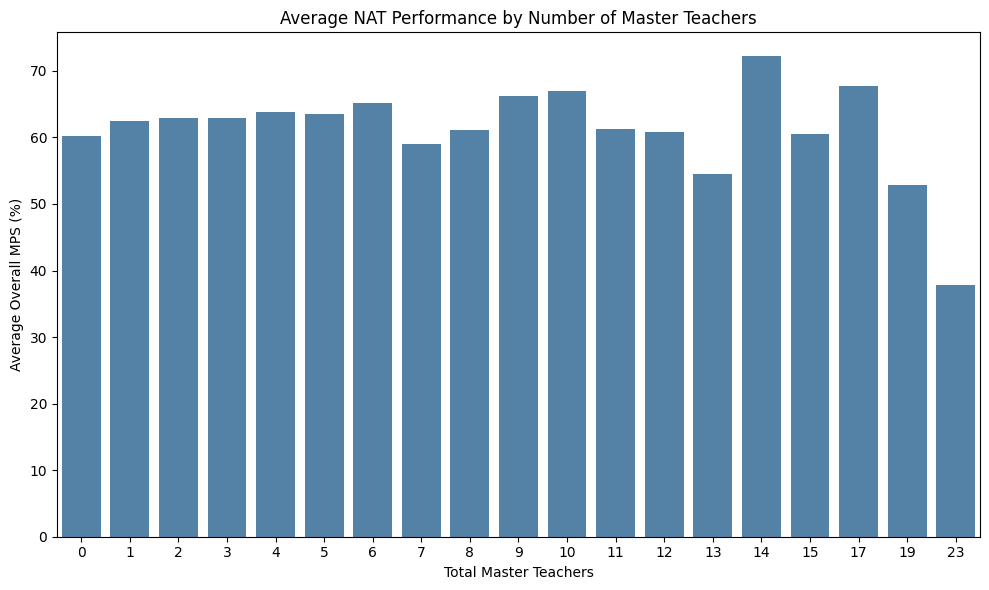

In [70]:
# Group by master teacher count and show average MPS
mt_grouped = master_teacher_ratio.groupby('total_master_teachers')['overall_mps'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=mt_grouped, x='total_master_teachers', y='overall_mps', color='steelblue')
plt.title('Average NAT Performance by Number of Master Teachers')
plt.xlabel('Total Master Teachers')
plt.ylabel('Average Overall MPS (%)')
plt.tight_layout()
plt.show()

In [71]:
master_teacher_ratio['has_master_teacher'] = master_teacher_ratio['total_master_teachers'] > 0

comparison = master_teacher_ratio.groupby('has_master_teacher')['overall_mps'].mean()
print(comparison)

has_master_teacher
False    60.221823
True     62.649409
Name: overall_mps, dtype: float64


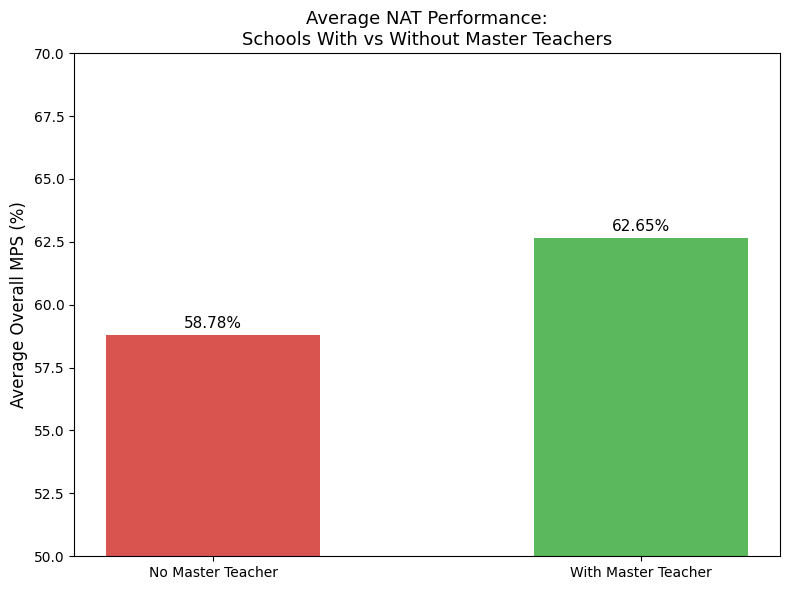

In [72]:
labels = ['No Master Teacher', 'With Master Teacher']
values = [58.784258, 62.649409]
colors = ['#d9534f', '#5cb85c']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='none')

ax.set_ylabel('Average Overall MPS (%)', fontsize=12)
ax.set_title('Average NAT Performance:\nSchools With vs Without Master Teachers', fontsize=13)
ax.set_ylim(50, 70)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.3, 
            f'{val:.2f}%', 
            ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## Insight

Schools with at least one Master Teacher recorded an average 
overall NAT MPS of 62.65% compared to 58.78% for schools 
with no Master Teachers — a difference of 3.87 percentage 
points.

While modest, this gap suggests that Master Teacher presence 
may contribute to improved instructional quality and student 
outcomes, consistent with their designated role as pedagogical 
leaders and mentors within the school.

However, causation cannot be established from this data alone. 
Schools with Master Teachers may also benefit from other 
correlated advantages — larger staff, better resources, or 
urban location — that independently contribute to higher 
performance.